# v2a-inspect Client Demo

This notebook shows the basic client flow against a running `v2a-inspect-server`. Server requests are guarded by `RUN_SERVER_REQUESTS` so the notebook can be opened and run locally without accidentally starting expensive inference.

In [1]:
from pathlib import Path

import httpx

from v2a_inspect.client import SAM3Client, VideoClient
from v2a_inspect.media_utils import probe_prepared_video
from v2a_inspect.models import VideoAsset
from v2a_inspect.preprocessing.scenes import detect_initial_scenes

In [2]:
SERVER_URL = "http://localhost:8080"
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "test.mp4").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
VIDEO_PATH = (PROJECT_ROOT / "test.mp4").resolve()
RUN_SERVER_REQUESTS = True

VIDEO_PATH

PosixPath('/home/riverfog7/Workspace/v2a_inspect/test.mp4')

## Local Video Inspection

The demo video is already in the prepared working-video format, so we can probe it and run local scene detection without contacting the server.

In [3]:
probe = probe_prepared_video(VIDEO_PATH)
video_asset = VideoAsset(source_path=probe.path, frame_count=probe.frame_count)
initial_scenes = detect_initial_scenes(video_asset)
video_asset = video_asset.model_copy(update={"initial_scenes": initial_scenes})

{
    "source_path": str(video_asset.source_path),
    "frame_count": video_asset.frame_count,
    "duration_sec": video_asset.duration_sec,
    "scene_count": len(video_asset.initial_scenes),
}

{'source_path': '/home/riverfog7/Workspace/v2a_inspect/test.mp4',
 'frame_count': 5264,
 'duration_sec': 175.46666666666667,
 'scene_count': 19}

In [4]:
initial_scenes

[InitialScene(initial_scene_id=UUID('1446d930-7b2d-4cb6-be04-39028413623d'), start_frame_index=0, end_frame_index=189, keyframes=[], initial_analysis=None, scene_tracks=[], frame_count=189),
 InitialScene(initial_scene_id=UUID('e1ff46d9-30e7-4c20-8a7e-f973035eade9'), start_frame_index=189, end_frame_index=279, keyframes=[], initial_analysis=None, scene_tracks=[], frame_count=90),
 InitialScene(initial_scene_id=UUID('8e63cc8b-0f0b-4b48-b50f-4bac2488ac02'), start_frame_index=279, end_frame_index=1183, keyframes=[], initial_analysis=None, scene_tracks=[], frame_count=904),
 InitialScene(initial_scene_id=UUID('fe6db893-2378-43a5-bf85-fbf0278dceb3'), start_frame_index=1183, end_frame_index=2244, keyframes=[], initial_analysis=None, scene_tracks=[], frame_count=1061),
 InitialScene(initial_scene_id=UUID('1e3a9122-e6fb-469a-a997-41d118710ff9'), start_frame_index=2244, end_frame_index=2548, keyframes=[], initial_analysis=None, scene_tracks=[], frame_count=304),
 InitialScene(initial_scene_id=U

## Select The Scene

The tracking request below uses the second detected scene, `initial_scenes[1]`. The API frame range is global and half-open: `[start_frame_index, end_frame_index)`. Returned track points also use global frame indexes.

In [5]:
SCENE_INDEX = 3
scene = video_asset.initial_scenes[SCENE_INDEX]
START_FRAME_INDEX = scene.start_frame_index
# END_FRAME_INDEX = scene.end_frame_index
END_FRAME_INDEX = 1500
# FRAME_INDEX = (START_FRAME_INDEX + END_FRAME_INDEX) // 2
FRAME_INDEX = START_FRAME_INDEX + 10
TEXT_PROMPT = "airplane"

{
    "scene_index": SCENE_INDEX,
    "start_frame_index": START_FRAME_INDEX,
    "end_frame_index": END_FRAME_INDEX,
    "frame_count": scene.frame_count,
    "seed_frame_index": FRAME_INDEX,
    "text_prompt": TEXT_PROMPT,
}

{'scene_index': 3,
 'start_frame_index': 1183,
 'end_frame_index': 1500,
 'frame_count': 1061,
 'seed_frame_index': 1193,
 'text_prompt': 'airplane'}

## Server Health Check

Set `RUN_SERVER_REQUESTS = True` in the config cell when the server is running and you want to exercise the HTTP clients.

In [6]:
if RUN_SERVER_REQUESTS:
    async with httpx.AsyncClient(base_url=SERVER_URL, timeout=30.0) as http_client:
        health = await http_client.get("/healthz")
        health.raise_for_status()
        print(health.json())
else:
    print("Skipped. Set RUN_SERVER_REQUESTS = True to call the server.")

{'status': 'ok'}


## Upload Video

Client instances must be used as async context managers. This uploads the full source once; the tracking API can still restrict SAM3 inference to a frame range.

In [7]:
video_id = None

if RUN_SERVER_REQUESTS:
    async with VideoClient(SERVER_URL) as video_client:
        upload_response = await video_client.upload(str(VIDEO_PATH))
        video_id = upload_response.video_id

video_id

'a68384e3-a866-4ac8-8bd7-524bd210a378'

## SAM3 Image Segmentation

This requests masks from the selected scene midpoint. Adjust `TEXT_PROMPT` for the object you want to segment.

In [8]:
if RUN_SERVER_REQUESTS and video_id is not None:
    seed = SAM3Client.seed_from_prompt(TEXT_PROMPT)
    async with SAM3Client(SERVER_URL, timeout=300.0) as sam_client:
        segment_response = await sam_client.segment_image(
            video_id=video_id,
            frame_index=FRAME_INDEX,
            seeds=[seed],
            max_masks=3,
        )
    print(segment_response.model_dump())
else:
    print("Skipped. Upload a video first with RUN_SERVER_REQUESTS = True.")

{'masks': [{'mask_id': '0', 'bbox_xyxy': (720.9999847412109, 246.00000143051147, 827.9999828338623, 289.00000154972076), 'mask_rle': '{"encoding":"coco_rle","size":[720,1280],"counts":"^Wk?1\\\\f06M00000O1000O1O10O01000O0100O10O10O01000O10O1000O010000O100O010O10O10O1000O0100O100N2N2L4L4O1O100O11O0000001O1N102N0O2N1O1O100O1O1O0O2O1O1O010O010O10O10O10O01O10O010000O010O010O01000O010O10O100O00100O100O11N101N1Oikl9"}', 'confidence': 0.9259259104728699, 'source_seed_index': 0}, {'mask_id': '1', 'bbox_xyxy': (542.0000076293945, 406.00001335144043, 639.0000057220459, 465.0000125169754), 'mask_rle': '{"encoding":"coco_rle","size":[720,1280],"counts":"h_m;4[f03N0O101O000001O10001N2OO10O010000O010O100iYOJRf07lYOJUf09O010O01O10O01O0100O010O101N101N1O100O1O0O2O0O101N100O100001O00002N3]OTZO<Sf0M2N1O00100O010O010O010O10O010O010O10O10O010O0100O00100O010O02N2N100O00O101O001NfaQ>"}', 'confidence': 0.921951174736023, 'source_seed_index': 1}, {'mask_id': '2', 'bbox_xyxy': (710.0, 428.0000066757202, 811.99

## SAM3 Video Tracking: Second Scene Only

This tracks only `[START_FRAME_INDEX, END_FRAME_INDEX)`. The server decodes that frame range into a temporary frame directory, runs SAM3 on the bounded range, and returns global frame indexes. No video transcode is performed.

In [9]:
RUN_TRACKING = True

if RUN_SERVER_REQUESTS and RUN_TRACKING and video_id is not None:
    seed = SAM3Client.seed_from_prompt(TEXT_PROMPT, frame_index=FRAME_INDEX)
    async with SAM3Client(SERVER_URL, timeout=900.0) as sam_client:
        tracking_response = await sam_client.track_video(
            video_id,
            seeds=[seed],
            start_frame_index=START_FRAME_INDEX,
            end_frame_index=END_FRAME_INDEX,
        )
    print({
        "track_count": len(tracking_response.tracks),
        "points_per_track": [len(track.points) for track in tracking_response.tracks],
        "first_frame_indexes": [
            track.points[0].frame_index for track in tracking_response.tracks if track.points
        ],
        "last_frame_indexes": [
            track.points[-1].frame_index for track in tracking_response.tracks if track.points
        ],
    })
else:
    print("Skipped. Set RUN_SERVER_REQUESTS = True and RUN_TRACKING = True to track video.")

{'track_count': 4, 'points_per_track': [317, 193, 171, 285], 'first_frame_indexes': [1193, 1193, 1193, 1193], 'last_frame_indexes': [1183, 1183, 1183, 1183]}


## Visualization

These cells use `v2a_inspect.visualization` helpers to render scene summaries, segmented images, and tracking overlays for notebook inspection.

In [10]:
from v2a_inspect.media_utils import extract_frame
from v2a_inspect.visualization import (
    display_image,
    display_video,
    render_scene_timeline,
    render_segmented_image,
    render_tracking_video,
    summarize_scenes,
    summarize_tracks,
)

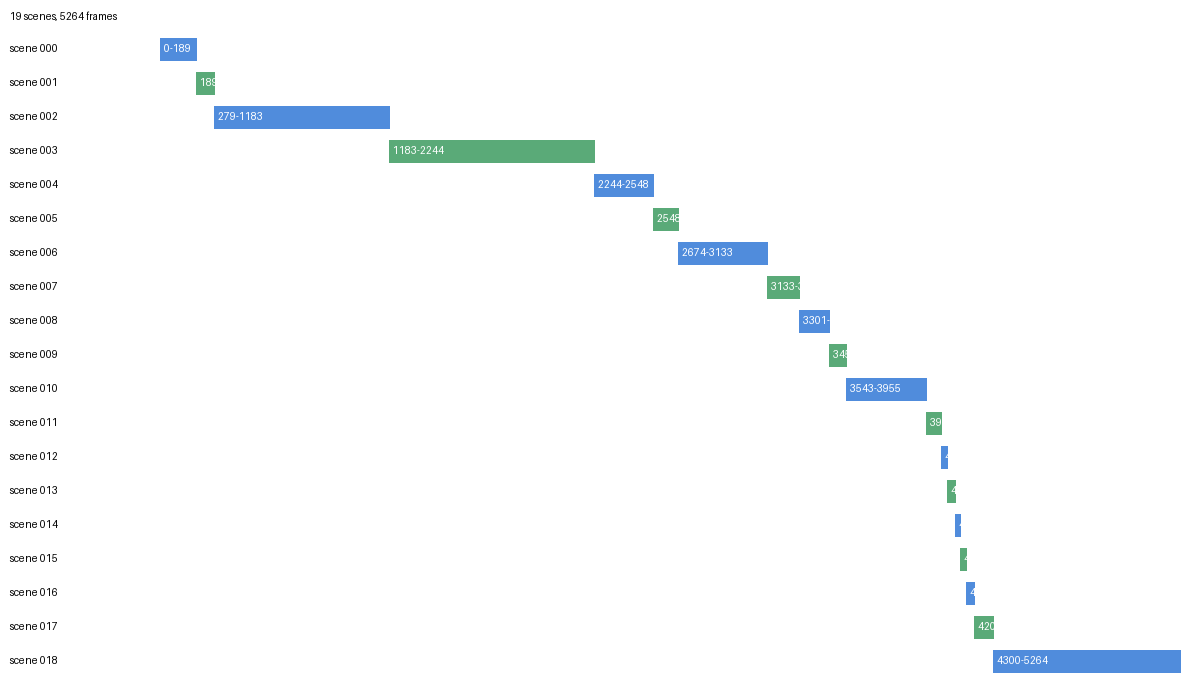

[{'scene_index': 0,
  'start_frame_index': 0,
  'end_frame_index': 189,
  'frame_count': 189,
  'duration_sec': 6.3,
  'keyframe_count': 0,
  'track_count': 0},
 {'scene_index': 1,
  'start_frame_index': 189,
  'end_frame_index': 279,
  'frame_count': 90,
  'duration_sec': 3.0,
  'keyframe_count': 0,
  'track_count': 0},
 {'scene_index': 2,
  'start_frame_index': 279,
  'end_frame_index': 1183,
  'frame_count': 904,
  'duration_sec': 30.133333333333333,
  'keyframe_count': 0,
  'track_count': 0},
 {'scene_index': 3,
  'start_frame_index': 1183,
  'end_frame_index': 2244,
  'frame_count': 1061,
  'duration_sec': 35.36666666666667,
  'keyframe_count': 0,
  'track_count': 0},
 {'scene_index': 4,
  'start_frame_index': 2244,
  'end_frame_index': 2548,
  'frame_count': 304,
  'duration_sec': 10.133333333333333,
  'keyframe_count': 0,
  'track_count': 0}]

In [11]:
scene_timeline_image = render_scene_timeline(video_asset)
display_image(scene_timeline_image)
summarize_scenes(video_asset)[:5]

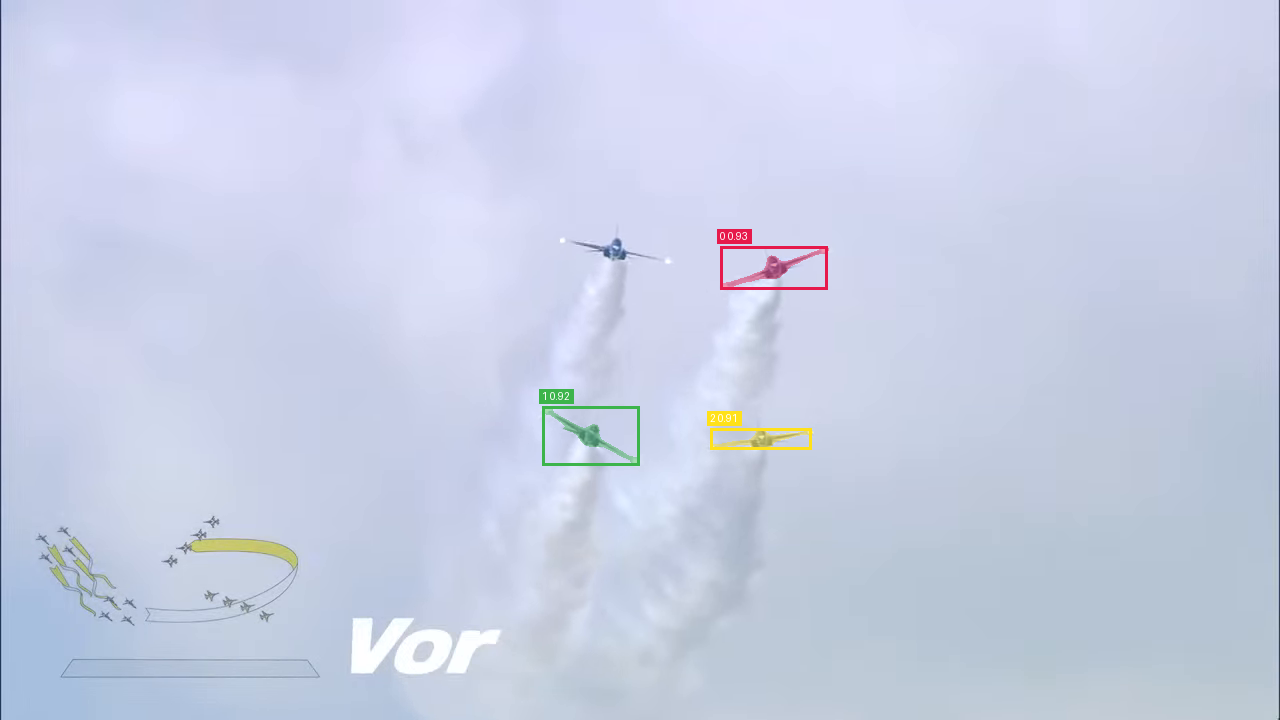

In [12]:
if "segment_response" in globals():
    segment_frame = extract_frame(VIDEO_PATH, FRAME_INDEX)
    segmented_image = render_segmented_image(segment_frame, segment_response)
    display_image(segmented_image)
else:
    print("No segment_response available. Run the SAM3 image segmentation cell first.")

In [13]:
if "tracking_response" in globals():
    visualization_dir = PROJECT_ROOT / "demo" / "outputs"
    tracking_overlay_path = visualization_dir / f"scene_{SCENE_INDEX:03d}_tracking_overlay.mp4"
    render_tracking_video(
        VIDEO_PATH,
        tracking_response,
        tracking_overlay_path,
        start_frame_index=START_FRAME_INDEX,
        end_frame_index=END_FRAME_INDEX,
    )
    display_video(tracking_overlay_path)
    summarize_tracks(tracking_response)
else:
    print("No tracking_response available. Run the SAM3 video tracking cell first.")

In [15]:
tracking_overlay_path

PosixPath('/home/riverfog7/Workspace/v2a_inspect/demo/outputs/scene_003_tracking_overlay.mp4')